# Data Overview — Walmart Store Sales Forecasting

Loads the raw Kaggle files, merges them into one table, handles missing values, and explores the data before any model-specific feature engineering happens. The cleaned output (`walmart_cleaned.csv`) is the shared starting point for every model_experiment file.

## Section 1 — Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', 100)
np.random.seed(42)

Mounted at /content/drive


## Section 2 — Load Raw Data

In [3]:
path = '/content/drive/MyDrive/ML-final/data/raw/'

train = pd.read_csv(path + 'train.csv')
stores = pd.read_csv(path + 'stores.csv')
features = pd.read_csv(path + 'features.csv')

print(train.shape, stores.shape, features.shape)

(421570, 5) (45, 3) (8190, 12)


## Section 3 — Explore Raw Data

In [4]:
print(f"{train['Store'].nunique()} stores, {train['Dept'].nunique()} depts, "
      f"{train.shape[0]} rows, dates {train['Date'].min()} to {train['Date'].max()}")
print(f"Holiday weeks: {train['IsHoliday'].mean()*100:.1f}%")
print(f"Store types: {stores['Type'].value_counts().to_dict()}, Size range: {stores['Size'].min()}–{stores['Size'].max()}")
print(f"Missing CPI/Unemployment rows (raw features.csv): {features['CPI'].isna().sum()}")

45 stores, 81 depts, 421570 rows, dates 2010-02-05 to 2012-10-26
Holiday weeks: 7.0%
Store types: {'A': 22, 'B': 17, 'C': 6}, Size range: 34875–219622
Missing CPI/Unemployment rows (raw features.csv): 585


## Section 4 — Merge Tables

In [5]:
df = train.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date'], how='left')

assert (df['IsHoliday_x'] == df['IsHoliday_y']).all(), "IsHoliday mismatch between train and features!"
df = df.drop(columns=['IsHoliday_y']).rename(columns={'IsHoliday_x': 'IsHoliday'})

df['Date'] = pd.to_datetime(df['Date'])

print("Merged shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

Merged shape: (421570, 16)
Missing values:
 Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64


## Section 5 — Handle Missing Values

In [6]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

na_before = df.isna().sum()
na_before = na_before[na_before > 0]
print("Missing values BEFORE cleaning:\n", na_before)

df[markdown_cols] = df[markdown_cols].fillna(0)

df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
df['CPI'] = df.groupby('Store')['CPI'].transform(lambda s: s.ffill().bfill())
df['Unemployment'] = df.groupby('Store')['Unemployment'].transform(lambda s: s.ffill().bfill())

na_after = df.isna().sum()
na_after = na_after[na_after > 0]
print("Missing values AFTER cleaning:", na_after if len(na_after) else "None remaining")

Missing values BEFORE cleaning:
 MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64
Missing values AFTER cleaning: None remaining


## Section 6 — Negative Sales Check

In [7]:
neg_sales = (df['Weekly_Sales'] < 0).sum()
neg_pct = neg_sales / len(df) * 100
print(f"Negative Weekly_Sales rows: {neg_sales} ({neg_pct:.3f}%)")

Negative Weekly_Sales rows: 1285 (0.305%)


## Section 7 — Sales Trend & Seasonality

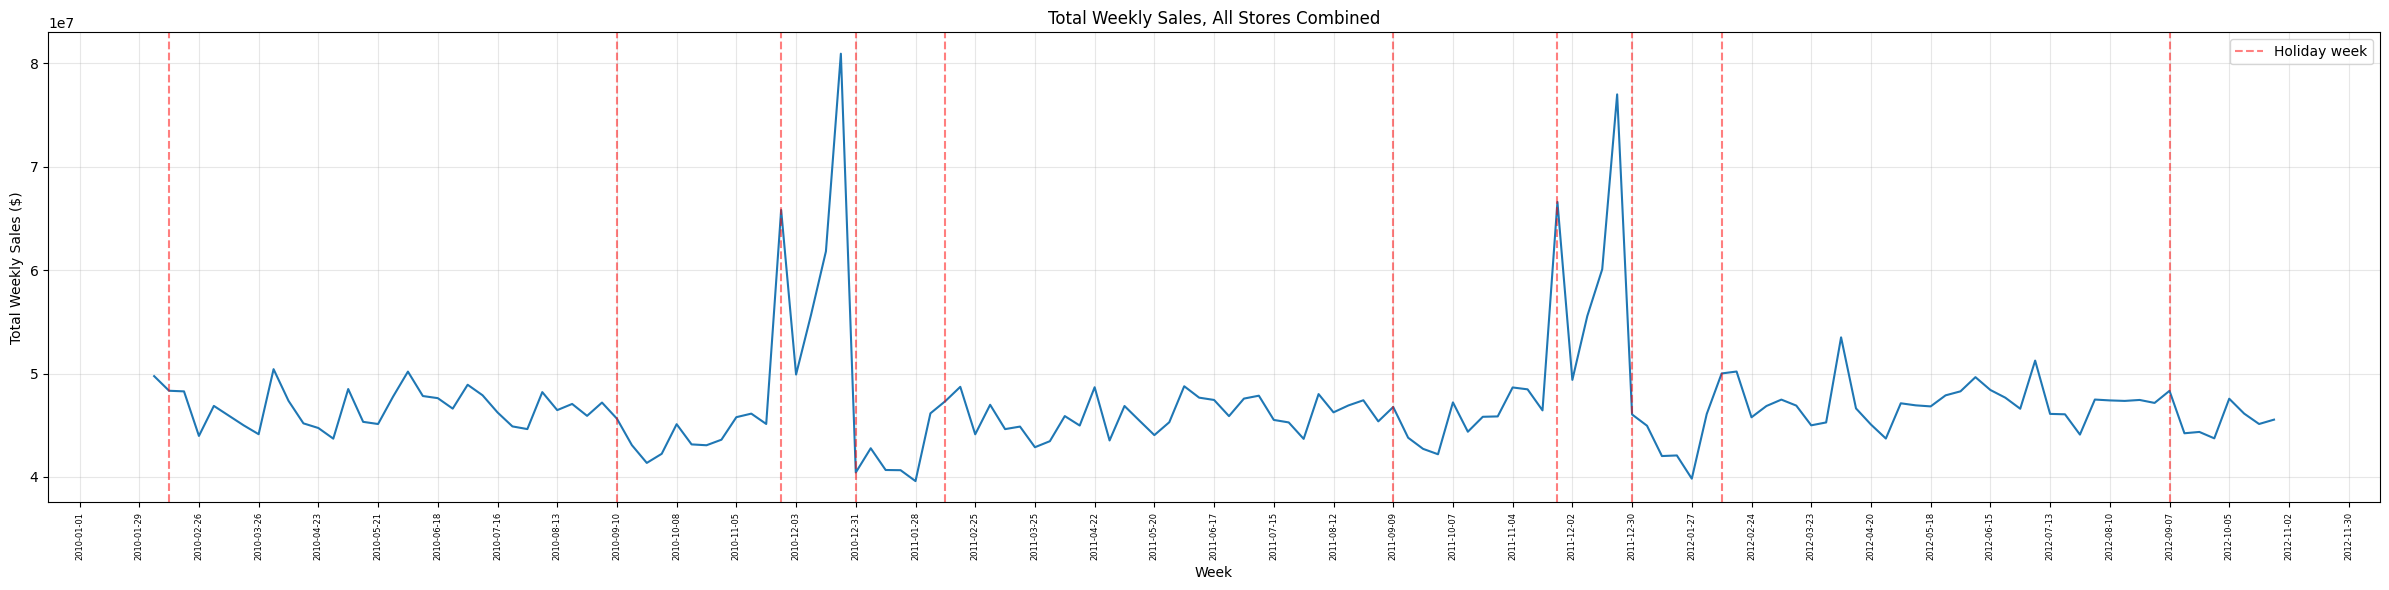

Top 5 highest-sales weeks:
         Date  Weekly_Sales
46 2010-12-24   80931415.60
98 2011-12-23   76998241.31
94 2011-11-25   66593605.26
42 2010-11-26   65821003.24
45 2010-12-17   61820799.85


In [16]:
import matplotlib.dates as mdates

WEEK_INTERVAL = 4

weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
holiday_weeks = pd.to_datetime(sorted(df.loc[df['IsHoliday'], 'Date'].unique()))

fig, ax = plt.subplots(figsize=(24, 6))
sns.lineplot(data=weekly_total, x='Date', y='Weekly_Sales', ax=ax)

for i, hdate in enumerate(holiday_weeks):
    ax.axvline(hdate, color='red', linestyle='--', alpha=0.5,
               label='Holiday week' if i == 0 else None)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.FR, interval=WEEK_INTERVAL))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=90, fontsize=6)

ax.set_title("Total Weekly Sales, All Stores Combined")
ax.set_xlabel("Week")
ax.set_ylabel("Total Weekly Sales ($)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 highest-sales weeks:")
print(weekly_total.sort_values('Weekly_Sales', ascending=False).head(5))

## Section 8 — Sales by Store Type

Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64


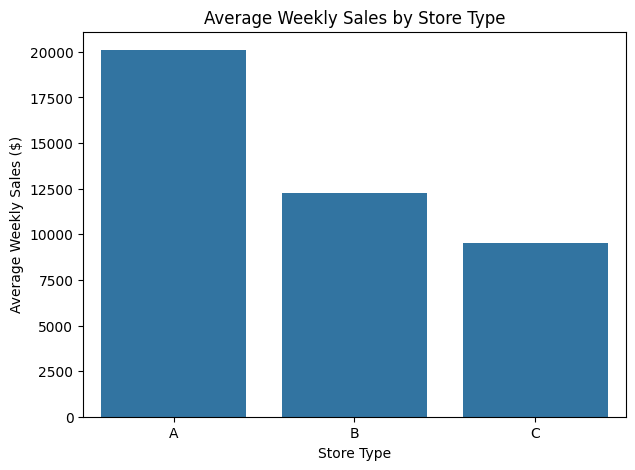

In [9]:
type_avg = df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)
print(type_avg)

plt.figure(figsize=(7, 5))
sns.barplot(x=type_avg.index, y=type_avg.values, order=type_avg.index)
plt.title("Average Weekly Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales ($)")
plt.show()

Type A stores sell noticeably more on average than B, and B more than C — consistent with A stores generally being the largest by square footage (see Section 3). Store Type/Size looks like a genuinely useful feature, not just noise.

## Section 9 — Sales by Department

Top 5 departments by average sales:
Dept
92    75204.870531
95    69824.423080
38    61090.619568
72    50566.515417
65    45441.706224
Name: Weekly_Sales, dtype: float64

Bottom 5 departments by average sales:
Dept
51    21.931729
39    11.123750
78     7.296638
43     1.193333
47    -7.682554
Name: Weekly_Sales, dtype: float64


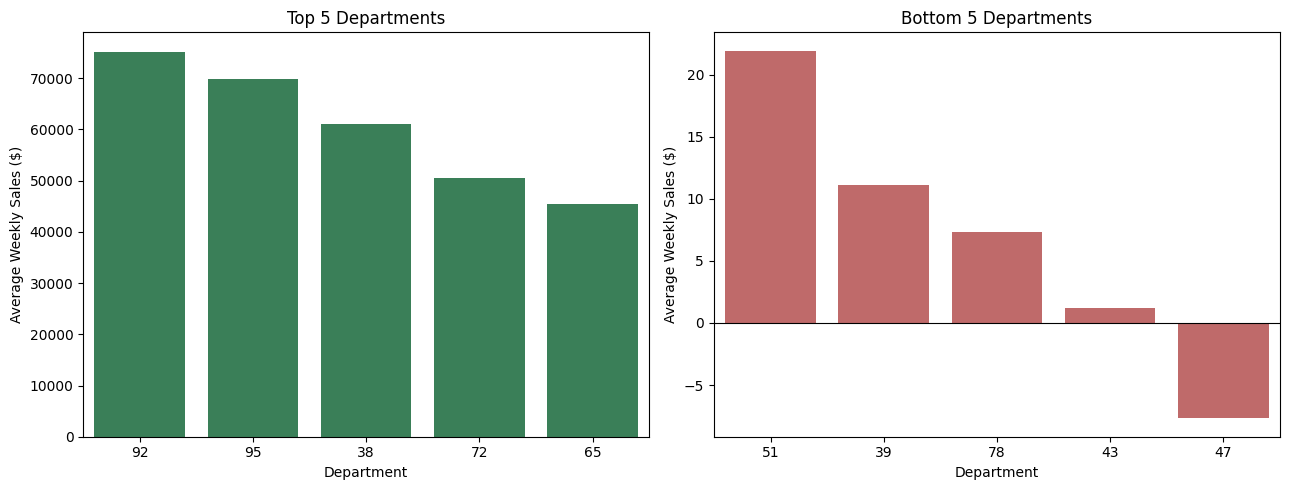

In [17]:
dept_avg = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)

top5 = dept_avg.head(5)
bottom5 = dept_avg.tail(5)

print("Top 5 departments by average sales:")
print(top5)
print("\nBottom 5 departments by average sales:")
print(bottom5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=top5.index.astype(str), y=top5.values, ax=axes[0], color='seagreen')
axes[0].set_title("Top 5 Departments")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Average Weekly Sales ($)")

sns.barplot(x=bottom5.index.astype(str), y=bottom5.values, ax=axes[1], color='indianred')
axes[1].set_title("Bottom 5 Departments")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Average Weekly Sales ($)")
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## Section 10 — Holiday Effects

Average sales, holiday vs non-holiday weeks:
IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

Average sales by specific holiday:
Thanksgiving    22220.944538
Super Bowl      16377.996441
Labor Day       15881.693339
Christmas       14543.387158
dtype: float64


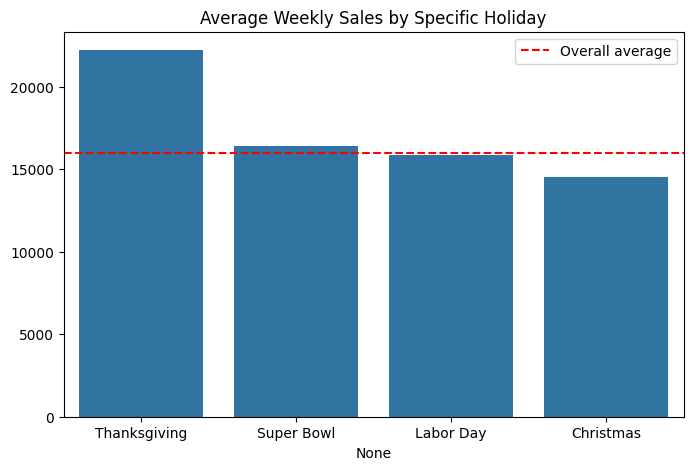

In [11]:
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean()
print("Average sales, holiday vs non-holiday weeks:")
print(holiday_avg)

holiday_dates = {
    'Super Bowl': ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'],
    'Labor Day': ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'],
    'Thanksgiving': ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'],
    'Christmas': ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'],
}

specific_holiday_avg = {}
for name, dates in holiday_dates.items():
    dates = pd.to_datetime(dates)
    specific_holiday_avg[name] = df.loc[df['Date'].isin(dates), 'Weekly_Sales'].mean()

specific_holiday_avg = pd.Series(specific_holiday_avg).sort_values(ascending=False)
print("\nAverage sales by specific holiday:")
print(specific_holiday_avg)

plt.figure(figsize=(8, 5))
sns.barplot(x=specific_holiday_avg.index, y=specific_holiday_avg.values)
plt.axhline(df['Weekly_Sales'].mean(), color='red', linestyle='--', label='Overall average')
plt.title("Average Weekly Sales by Specific Holiday")
plt.legend()
plt.show()

## Section 11 — Correlation with External Factors

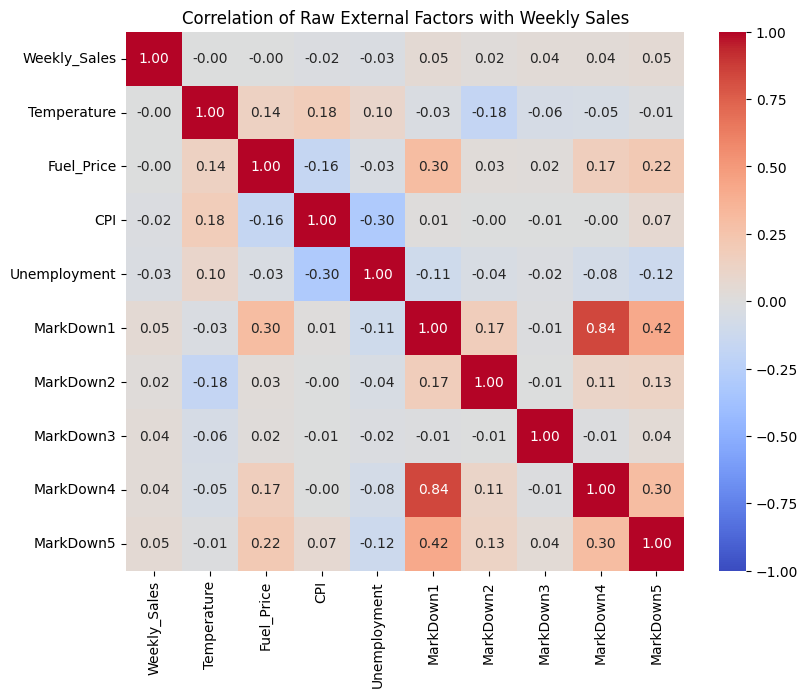

Weekly_Sales    1.000000
MarkDown5       0.050465
MarkDown1       0.047172
MarkDown3       0.038562
MarkDown4       0.037467
MarkDown2       0.020716
Fuel_Price     -0.000120
Temperature    -0.002312
CPI            -0.020921
Unemployment   -0.025864
Name: Weekly_Sales, dtype: float64


In [12]:
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'] + markdown_cols
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Raw External Factors with Weekly Sales")
plt.show()

print(corr_matrix['Weekly_Sales'].sort_values(ascending=False))

## Section 12 — Autocorrelation (ACF / PACF)

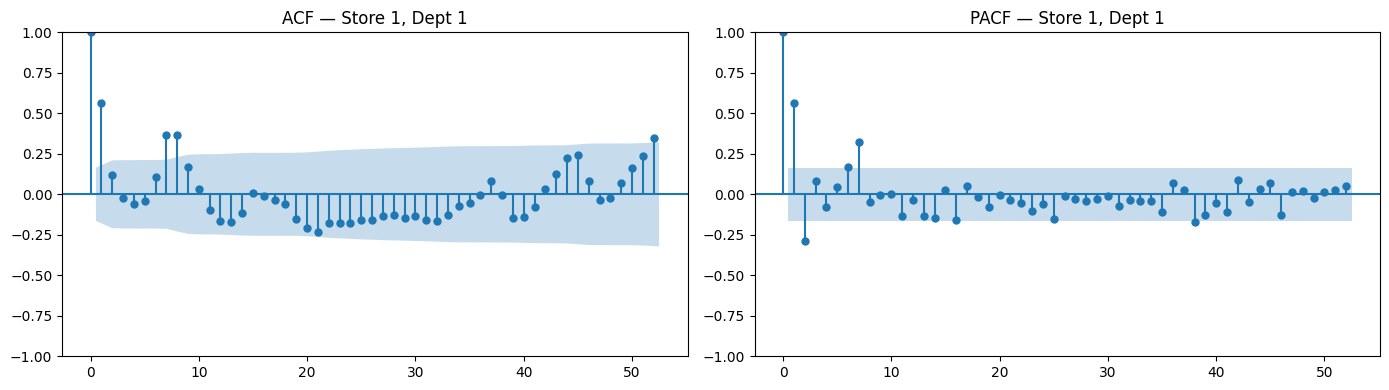

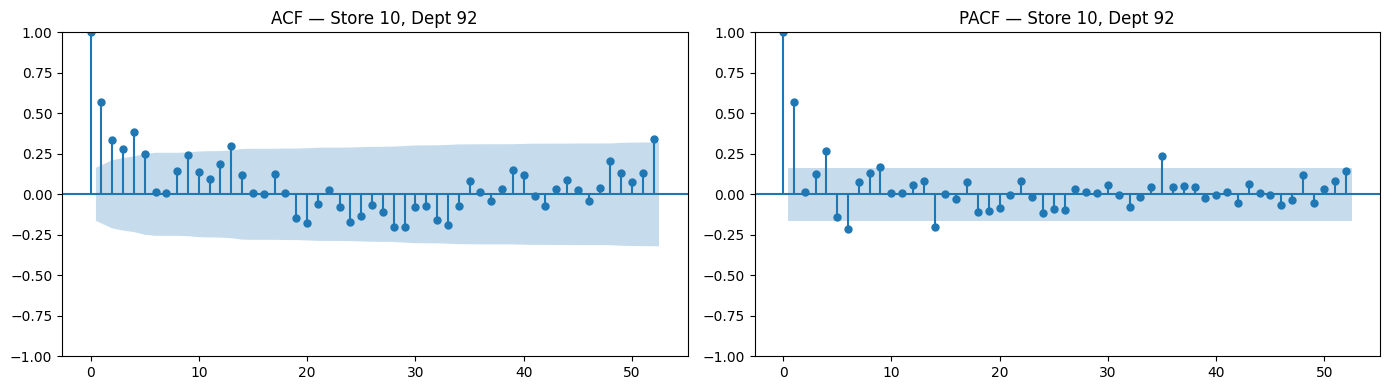

In [13]:
def plot_acf_pacf(data, store_id, dept_id, lags=52):
    series = (data[(data['Store'] == store_id) & (data['Dept'] == dept_id)]
              .sort_values('Date')['Weekly_Sales'])
    if series.empty:
        print(f"No data for Store {store_id}, Dept {dept_id}")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series, lags=lags, ax=axes[0], title=f"ACF — Store {store_id}, Dept {dept_id}")
    plot_pacf(series, lags=lags, ax=axes[1], title=f"PACF — Store {store_id}, Dept {dept_id}")
    plt.tight_layout()
    plt.show()

plot_acf_pacf(df, store_id=1, dept_id=1)
plot_acf_pacf(df, store_id=10, dept_id=92)

## Section 13 — Save Cleaned Data

In [14]:
import os
out_dir = '/content/drive/MyDrive/ML-final/data/processed/'
os.makedirs(out_dir, exist_ok=True)

out_path = out_dir + 'walmart_cleaned.csv'
df.to_csv(out_path, index=False)

print(f"Saved cleaned data: {df.shape[0]} rows, {df.shape[1]} cols -> {out_path}")

Saved cleaned data: 421570 rows, 16 cols -> /content/drive/MyDrive/ML-final/data/processed/walmart_cleaned.csv


---
**This file (`walmart_cleaned.csv`) is the shared input for every `model_experiment_*.ipynb` notebook.** Notice `Type` is still 'A'/'B'/'C' and `IsHoliday` is still True/False here — kept human-readable on purpose. Numeric encoding (and any other model-specific feature engineering) happens separately inside each model's own notebook, since different model families may want different representations.